In [1]:
import cmdstanpy
import matplotlib.pyplot as plt
import numpy as np
import pyreadr
from cmdstanpy import CmdStanModel
cmdstanpy.install_cmdstan();

CmdStan install directory: /Users/cwf25/.cmdstan
CmdStan version 2.38.0 already installed
Test model compilation


In [2]:
seed = 739485
rng = np.random.default_rng(seed)

In [3]:
df = pyreadr.read_r('data/tutorial.Rda')[None]
df.head().style.hide(axis='index')

y,time
0.795570,0.000000
0.174560,0.500000
0.774322,1.000000
3.083851,1.500000
2.163227,2.000000


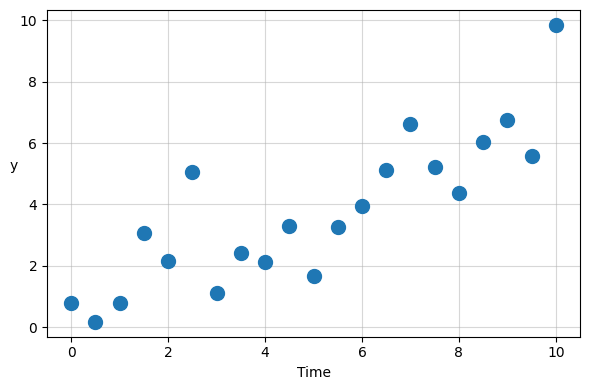

In [41]:
fig, ax = plt.subplots(figsize=(6, 4))
ax.grid(alpha=.5)
ax.scatter(df['time'], df['y'], s=100, zorder=2)
ax.set_xlabel('Time')
ax.set_ylabel(ylabel='y', rotation=0)
fig.tight_layout()

In [25]:
# Only want to solve the ODE at unique time points to reduce runtime
time = np.sort(df['time'].unique())

# Dictionary of data corresponding to the model definition in 'cmdstanpy.stan'
data = {
    'N': len(df),
    'T': len(time),
    'y': df['y'].to_numpy(),
    't': time,
    't_idx': [np.where(df == t)[0].item() + 1 for t in df['time']],
    'include_likelihood': True
}

In [29]:
model = CmdStanModel(stan_file='tutorial.stan')
fit = model.sample(data, chains=4, seed=seed)

17:50:05 - cmdstanpy - INFO - CmdStan start processing


chain 1:   0%|          | 0/2000 [00:00<?, ?it/s, (Warmup)]

chain 2:   0%|          | 0/2000 [00:00<?, ?it/s, (Warmup)]

chain 3:   0%|          | 0/2000 [00:00<?, ?it/s, (Warmup)]

chain 4:   0%|          | 0/2000 [00:00<?, ?it/s, (Warmup)]

17:50:05 - cmdstanpy - INFO - CmdStan done processing.
17:50:05 - cmdstanpy - WARNING - Non-fatal error during sampling:
Exception: ode_rk45: ode parameters and data is inf, but must be finite! (in 'tutorial.stan', line 31, column 4 to column 59)
Exception: ode_rk45: ode parameters and data is inf, but must be finite! (in 'tutorial.stan', line 31, column 4 to column 59)
Exception: ode_rk45: ode parameters and data is inf, but must be finite! (in 'tutorial.stan', line 31, column 4 to column 59)
Consider re-running with show_console=True if the above output is unclear!


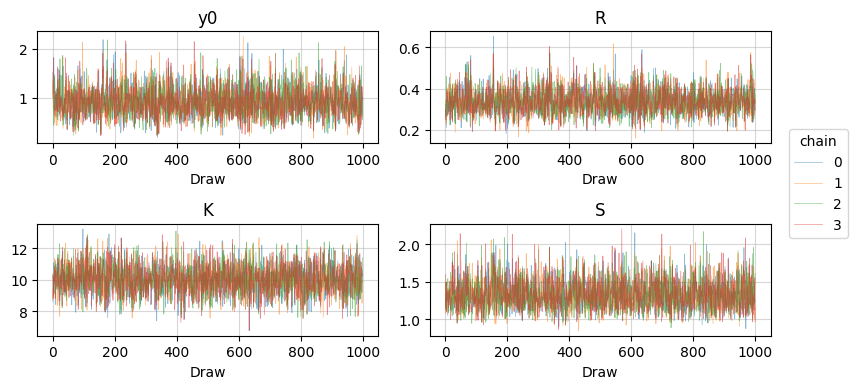

In [43]:
params = ('y0', 'R', 'K', 'S')
n_draws = len(draws := fit.draws_pd())
n_chains = len(draws['chain__'].unique())
fig, axes = plt.subplots(round(len(params)/2), 2, figsize=(8, 4))

for ax, param in zip(axes.flatten(), params):
    ax.grid(alpha=.5)
    param_draws = draws[param].to_numpy().reshape(n_draws//n_chains, n_chains)
    lines = ax.plot(param_draws, alpha=.5, linewidth=.5)
    ax.set(title=param, xlabel='Draw')

fig.legend(lines, np.arange(n_chains), title='chain', bbox_to_anchor=(1.08, .68))
fig.tight_layout()

In [9]:
fit.summary().head()[1:]

,Mean,MCSE,StdDev,MAD,5%,50%,95%,ESS_bulk,ESS_tail,ESS_bulk/s,R_hat
y0,0.924321,0.006534,0.307237,0.297232,0.472000,0.899739,1.457460,2160.23,1987.91,2394.93,1.00121
R,0.338424,0.001417,0.061694,0.059496,0.246105,0.332705,0.445191,2007.41,1875.76,2225.51,1.00167
K,10.034300,0.018599,0.935141,0.933965,8.501400,10.024100,11.611100,2604.40,2525.45,2887.36,1.00166
S,1.331010,0.004052,0.203093,0.198705,1.040970,1.305110,1.697340,2635.63,2511.21,2921.99,1.00193


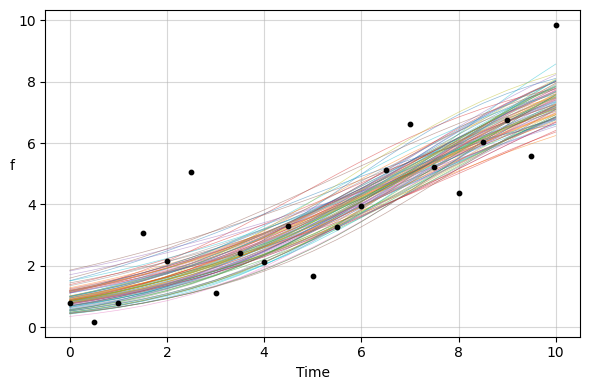

In [42]:
keys = [f'z_rep[{i + 1}]' for i in range(0, stan_data['N'])]
sample_idx = rng.integers(0, n_draws, 100)
z = draws[keys].loc[sample_idx].T.to_numpy()
fig, ax = plt.subplots(figsize=(6, 4))
ax.grid(alpha=.5)
ax.plot(stan_data['t'], z, alpha=.5, linewidth=.5)
ax.scatter(df['time'], df['y'], s=10, c='black', zorder=2)
ax.set_xlabel('Time')
ax.set_ylabel('f', rotation=0)
fig.tight_layout()